In [ ]:
from astrovision.plot.plot_utils import make_mosaic
from astrovision.data import SatelliteImage, SegmentationLabeledSatelliteImage
import s3fs
import os
import geopandas as gpd
from pyproj import CRS
import matplotlib.pyplot as plt
import pandas as pd
import folium
import numpy as np
import math
import ipywidgets as widgets
from ipywidgets import interact

from IPython.display import clear_output

In [ ]:
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://" + "minio.lab.sspcloud.fr"})
out  = fs.download(rpath="projet-slums-detection/ilots", lpath="ilots", recursive=True)
out = fs.download(rpath="projet-slums-detection/data-prediction/PLEIADES/MAYOTTE", lpath="pred_mayotte", recursive=True)

pred_2020 = gpd.read_file('pred_mayotte/2020/predictions.gpkg')
pred_2023 = gpd.read_file('pred_mayotte/2023/predictions.gpkg')
ilots = gpd.read_file("ilots/ilots.gpkg")
tgt_crs = CRS.from_epsg(4471) # mayotte 

pred_2020 = pred_2020.to_crs(tgt_crs)
pred_2023 = pred_2023.to_crs(tgt_crs)

pred_2020["area"] = pred_2020.area
pred_2023["area"] = pred_2023.area

ilots = ilots.to_crs(tgt_crs)
ilotsMayotte = ilots[ilots["ident_ilot"].str.startswith('976')]
ilotsMayotte["area"] = ilotsMayotte.geometry.area

In [ ]:
intersection_2020 = gpd.overlay(pred_2020, ilotsMayotte, how='intersection')
intersection_2023 = gpd.overlay(pred_2023, ilotsMayotte, how='intersection')

In [ ]:
intersection_2020["area_pred_inter_ilot"] = intersection_2020.geometry.area
intersection_2023["area_pred_inter_ilot"] = intersection_2020.geometry.area

aire_inter_2020 = intersection_2020.groupby('ident_ilot')['area_pred_inter_ilot'].sum()
aire_inter_2023 = intersection_2023.groupby('ident_ilot')['area_pred_inter_ilot'].sum()

comp_area = pd.merge(aire_inter_2020,aire_inter_2023,how = 'outer', on = 'ident_ilot', suffixes=('_2020', '_2023'))

comp_area["diff_area"] = comp_area["area_pred_inter_ilot_2023"] - comp_area["area_pred_inter_ilot_2020"]
comp_area["evol_pct_area"] = round((comp_area["diff_area"]/comp_area["area_pred_inter_ilot_2020"])*100,2)

In [ ]:
comp_area = comp_area.sort_values(['diff_area'], ascending = False)
comp_area

Du coup on veut évaluer graphiquement les raisons des évolutions les plus marquées. 
Pour ce faire on représente sur une meme carte en rouge les créations 2023 ( parts de polygone de pred 2023 non intersectée avec du 2020)
en bleu  les destructions 2023 ( parts de polygone de pred 2020 non intersectée avec du 2023)

In [ ]:
# sym_diff = pred_2020.symmetric_difference(pred_2023)
sym_diff = gpd.overlay(pred_2020, pred_2023, how='symmetric_difference')
index = pd.RangeIndex(stop=len(sym_diff))
sym_diff = gpd.GeoDataFrame(sym_diff, crs='EPSG:4471', index=index)

polygones_commun = gpd.overlay(pred_2020, pred_2023, how='intersection')
resultat = sym_diff[~sym_diff.geometry.isin(polygones_commun.geometry)]

# suppression = gpd.sjoin(sym_diff, pred_2020, how='inner', op='intersects')
# creation = gpd.sjoin(sym_diff, pred_2023, how='inner', op='intersects')


In [ ]:
resultat_2020 = gpd.sjoin(resultat, pred_2020, how='left', op='within')
suppression = resultat_2020[resultat_2020.index_right.isna()]
suppression = suppression.loc[:, resultat.columns]
suppression = suppression.drop('area_1', axis=1)

resultat_2023 = gpd.sjoin(resultat, pred_2023, how='left', op='within')
creation = resultat_2023[resultat_2023.index_right.isna()]
creation = creation.loc[:, resultat.columns]
creation = creation.drop('area_1', axis=1)


In [ ]:
# intersection ilots creation destruction
ilots_inter_creation = gpd.overlay(creation, ilotsMayotte, how='intersection')
ilots_inter_creation["type"] = "creation"

ilots_inter_suppression = gpd.overlay(suppression, ilotsMayotte, how='intersection')
ilots_inter_suppression["type"] = "suppression"

df_diff = pd.concat([ilots_inter_creation, ilots_inter_suppression])

In [ ]:
ident_ilot =  "976110306" 
diff_ilot = df_diff.loc[df_diff.ident_ilot  == ident_ilot] 	
contour_ilot  = ilotsMayotte[ilotsMayotte.ident_ilot == ident_ilot]


In [ ]:
diff_ilot = diff_ilot.to_crs(4326)
contour_ilot = contour_ilot.to_crs(4326)

center = list(contour_ilot.iloc[0]['geometry'].centroid.coords)[0]
center =  (center[1],center[0])

carte = folium.Map(location=center, zoom_start=10)

folium.GeoJson(contour_ilot,style_function=lambda x: {"color": "yellow"}).add_to(carte)

# Ajouter les polygones de type "creation" en rouge
for index, row in diff_ilot[diff_ilot["type"] == "creation"].iterrows():
    folium.GeoJson(row["geometry"],  style_function=lambda x: {"color": "red"}, tooltip=row["ident_ilot"]).add_to(carte)

# Ajouter les polygones de type "suppression" en bleu
for index, row in diff_ilot[diff_ilot["type"] == "suppression"].iterrows():
    folium.GeoJson(row["geometry"], style_function=lambda x: {"color": "blue"}, tooltip=row["ident_ilot"]).add_to(carte)


In [ ]:
carte
# TO DO  : ajouter des controles cliquer decliquer
# ajouter couche popred_2020 pred_2023, creation, suppression
#indice de gravlus ? pour dégager les formes longilignes

In [ ]:
diff_ilot['compacite'] = (4 * math.pi * diff_ilot.area) / (diff_ilot.length**2)

# Afficher les 5 premières lignes de la table
print(diff_ilot.head())

In [ ]:
diff_ilot['compacite'].describe()

In [66]:
# Fonction pour mettre à jour la carte en fonction du seuil de compacité
def update_map(s):
    # Créer une carte
    center = list(contour_ilot.iloc[0]['geometry'].centroid.coords)[0]
    center = (center[1], center[0])
    carte = folium.Map(location=center, zoom_start=16)
    
    # Ajouter une couche de base à la carte
    folium.GeoJson(contour_ilot, style_function=lambda x: {"color": "yellow"}).add_to(carte)
    
    # Ajouter les polygones de type "creation" dont la compacité est supérieure au seuil
    creation_mask = (diff_ilot['type'] == 'creation') & (diff_ilot['compacite'] > s)
    for _, row in diff_ilot[creation_mask].iterrows():
        folium.GeoJson(row['geometry'], style_function=lambda x: {'color': 'red'}).add_to(carte)
    
    # Ajouter les polygones de type "suppression" dont la compacité est supérieure au seuil
    suppression_mask = (diff_ilot['type'] == 'suppression') & (diff_ilot['compacite'] > s)
    for _, row in diff_ilot[suppression_mask].iterrows():
        folium.GeoJson(row['geometry'], style_function=lambda x: {'color': 'blue'}).add_to(carte)
    
    # Afficher la carte
    display(carte)

# Créer un widget de barre de défilement interactif
s_slider = widgets.FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5, description='Seuil de compacité')

# Lier la fonction de mise à jour de la carte au widget de barre de défilement interactif
widgets.interact(update_map, s=s_slider)

interactive(children=(FloatSlider(value=0.5, description='Seuil de compacité', max=1.0, step=0.01), Output()),…

<function __main__.update_map(s)>

/tmp/ipykernel_282749/1787853931.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  surfacetotale = sum(diff_ilot['geometry'].area)


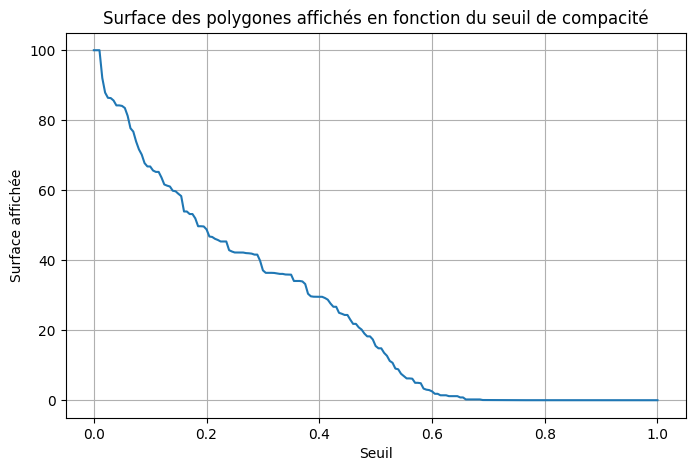

,seuil,aire
0,0.000,100.000000
1,0.005,100.000000
2,0.010,100.000000
3,0.015,92.072240
4,0.020,87.899666
...,...,...
196,0.980,0.000000
197,0.985,0.000000
198,0.990,0.000000
199,0.995,0.000000


In [65]:
surface = pd.DataFrame(columns=['seuil', 'aire'])
surfacetotale = sum(diff_ilot['geometry'].area)
for i in range(0, 201):
    surfaces = []
    i = i / 200 
    s = i 
    creation_mask = (diff_ilot['type'] == 'creation') & (diff_ilot['compacite'] > s)
    for _, row in diff_ilot[creation_mask].iterrows():
        surfaces.append(row['geometry'].area)
    suppression_mask = (diff_ilot['type'] == 'suppression') & (diff_ilot['compacite'] > s)
    for _, row in diff_ilot[suppression_mask].iterrows():
        surfaces.append(row['geometry'].area)
    aire = 100 * sum(surfaces) / surfacetotale
    surface.loc[len(surface)] = [s, aire]


plt.figure(figsize=(8, 5))
plt.plot(surface['seuil'], surface['aire'])
plt.xlabel('Seuil')
plt.ylabel('Surface affichée')
plt.title('Surface des polygones affichés en fonction du seuil de compacité')
plt.grid(True)
plt.show()

surface

In [ ]:
# Supposons que 'surface' est votre DataFrame contenant les données de surface affichée en fonction du seuil

# Calculer la différence de surface affichée
surface['diff_surface'] = surface['aire'].diff()

# Calculer la différence de seuil
surface['diff_seuil'] = surface['seuil'].diff()

# Calculer la dérivée comme la variation de la surface affichée divisée par la variation du seuil
surface['derivee'] = surface['diff_surface'] / surface['diff_seuil']

# Afficher la courbe de la dérivée
plt.figure(figsize=(8, 5))
plt.plot(surface['seuil'], surface['derivee'])
plt.xlabel('Seuil')
plt.ylabel('Dérivée de la surface affichée')
plt.title('Dérivée de la surface des polygones affichés en fonction du seuil de compacité')
plt.grid(True)
plt.show()
